# Oronto Group Age Depth Modeling

This notebook is for developing a Chron.jl age model for the Oronto Group

In [1]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

In [2]:
Oronto_Name = ("Lake Shore Traps", "Nonesuch", "Upper Freda DZ", "Montreal River Monocline") # Et cetera
Oronto_Age           = [   1085.6,   1078,    1052, 1050] # Measured ages
Oronto_Age_sigma     = [        0.65,       24,    0.85,5] # Measured 1-σ uncertainties
Oronto_Height        = [    1300,    1800,5800         ,6000] # Depths below surface should be negative
Oronto_Age_Sidedness = [       0,        0,           -1,1] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Oronto_Path = "../../data/age_models_output/Oronto_Group" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Oronto_section = make_ChronAgeData(Oronto_Name, Oronto_Age, Oronto_Age_sigma, Oronto_Height, Oronto_Age_Sidedness, Oronto_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{4}(("Lake Shore Traps", "Nonesuch", "Upper Freda DZ", "Montreal River Monocline"), [1300.0, 1800.0, 5800.0, 6000.0], [0.01, 0.01, 0.01, 0.01], [1085.6, 1078.0, 1052.0, 1050.0], [0.65, 24.0, 0.85, 5.0], [NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN], [0.0, 0.0, -1.0, 1.0], [0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN NaN NaN; NaN NaN NaN NaN; … ; NaN NaN NaN NaN; NaN NaN NaN NaN], "../../data/age_models_output/Oronto_Group", 2, "Ma", "m", :cdf)

In [3]:
Oronto_age_model_config, Oronto_age_model_mdl, Oronto_age_model_agedist, Oronto_age_model_lldist = run_age_model(Oronto_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 659000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 659000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 659000, 1000, 659, 0.2), StratAgeModel([1300.0, 1310.0, 1320.0, 1330.0, 1340.0, 1350.0, 1360.0, 1370.0, 1380.0, 1390.0  …  5910.0, 5920.0, 5930.0, 5940.0, 5950.0, 5960.0, 5970.0, 5980.0, 5990.0, 6000.0], [1085.7081746899537, 1085.5717007752853, 1085.3877492403692, 1085.1854794803933, 1084.9897541283483, 1084.8309761384146, 1084.7064322293902, 1084.5195325196637, 1084.4130109659588, 1084.2724959869176  …  1048.2141109585168, 1048.1985938046905, 1048.172537276164, 1048.1535708396693, 1048.1310472780465, 1048.1062739245017, 1048.0753965386136, 1048.063941588984, 1048.038803380416, 1047.9993938901596], [0.6612808204858038, 1.1006231517413336, 1.531491010134578, 1.857357531378751, 2.1671576856758543, 2.407161160655284, 2.5730201429006736, 2.7256343740345748, 2.8089100109278533, 2.9095905722871693  …  2.7686234230951157, 2.771707382893528, 2.778556723764422, 2.7782879304635757, 2.79690573670566, 2.8011053332534455, 2.805125599824489, 2.8083067396704826, 2.80

In [4]:
hdl = plot(framestyle=:box,
fg_color_legend=:white,
xlabel="Age ($(Oronto_section.Age_Unit))",
ylabel="Height ($(Oronto_section.Height_Unit))",
);

### posterior summary age model

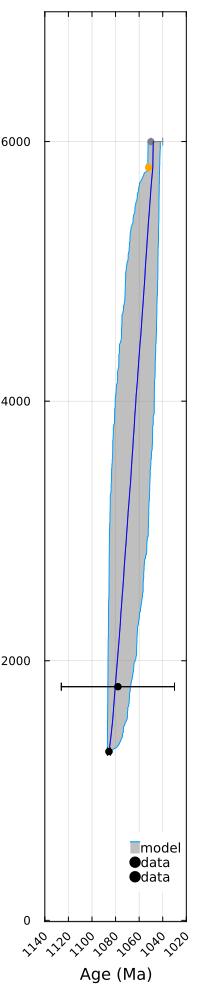

In [5]:
Oronto_age_model = plot_age_model(Oronto_section, Oronto_age_model_mdl, save_figure=false)

plot!(Oronto_age_model, Oronto_age_model_mdl.Age, Oronto_age_model_mdl.Height, linecolor=:blue, label="") # Center line
t = Oronto_section.Age_Sidedness .== 0 # Two-sided constraints (plot in black)
any(t) && plot!(Oronto_age_model, Oronto_section.Age[t], Oronto_section.Height[t], xerror=2*Oronto_section.Age_sigma[t],label="data",seriestype=:scatter,color=:black)
t = Oronto_section.Age_Sidedness .== 1 # Minimum ages (plot in cyan)
# any(t) && plot!(Oronto_age_model, Oronto_section.Age[t], Oronto_section.Height[t], xerror=(2*Oronto_section.Age_sigma[t],zeros(count(t))),label="",seriestype=:scatter,color=:cyan,msc=:cyan)
# any(t) && zip(Oronto_section.Age[t], Oronto_section.Age[t].+nanmean(Oronto_section.Age_sigma[t])*2, Oronto_section.Height[t]) .|> x-> plot!([x[1],x[2]],[x[3],x[3]], arrow=true, label="", color=:cyan)
t = Oronto_section.Age_Sidedness .== -1 # Maximum ages (plot in orange)
# any(t) && plot!(Oronto_age_model, Oronto_section.Age[t], Oronto_section.Height[t], xerror=(zeros(count(t)),2*Oronto_section.Age_sigma[t]),label="",seriestype=:scatter,color=:orange,msc=:orange)
any(t) && zip(Oronto_section.Age[t], Oronto_section.Age[t].-nanmean(Oronto_section.Age_sigma[t])*2, Oronto_section.Height[t]) .|> x-> 
plot!(Oronto_age_model, xflip=true)

plot!(xlim=(1020,1140 ), ylim=(-10, 7000))
# savefig(Oronto_age_model, Oronto_section.Path*"_AgeDepthModel.pdf")
display(Oronto_age_model)

## save the age models to a file

In [6]:
Oronto_age_model_agedist

471×1000 Matrix{Float64}:
 1085.7   1084.98  1085.14  1084.82  …  1086.22  1085.36  1085.83  1085.07
 1085.7   1084.98  1085.14  1084.82     1084.01  1085.36  1085.83  1084.72
 1085.7   1084.98  1085.14  1084.82     1084.01  1085.36  1084.85  1084.72
 1085.7   1084.98  1085.14  1084.82     1084.01  1085.36  1084.85  1084.72
 1085.7   1084.98  1085.14  1084.82     1084.01  1085.36  1084.85  1084.72
 1085.7   1084.98  1083.37  1084.82  …  1084.01  1085.36  1084.85  1084.72
 1085.7   1084.98  1083.37  1084.82     1084.01  1085.36  1084.85  1084.72
 1085.7   1084.98  1083.37  1084.82     1084.01  1085.36  1084.85  1084.72
 1085.7   1084.98  1083.37  1084.82     1084.01  1085.36  1084.85  1084.72
 1085.7   1084.98  1083.37  1084.82     1084.01  1085.36  1084.85  1084.72
    ⋮                                ⋱                             
 1051.27  1049.07  1050.31  1049.09     1047.75  1048.45  1046.64  1041.25
 1051.27  1049.07  1050.31  1049.09     1047.75  1048.45  1046.64  1041.25
 1051.

In [7]:
# use the mdl.height as index, agedist as the data
Oronto_age_models_df = DataFrame(hcat(Oronto_age_model_mdl.Height, Oronto_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Oronto_age_models_df, Dict(:x1 => "height"))
Oronto_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,1300.0,1085.7,1084.98,1085.14,1084.82,1086.19,1084.32,1085.11,1086.66,1085.8,1085.73,1086.27,1085.22,1086.34,1086.29,1085.83,1084.72,1085.38,1084.41,1085.3,1086.03,1086.64,1084.94,1087.01,1085.09,1085.91,1085.38,1085.82,1084.83,1087.0,1086.12,1084.87,1085.2,1085.1,1085.83,1084.63,1085.61,1085.72,1086.14,1085.17,1086.86,1085.17,1085.77,1085.93,1085.97,1087.09,1086.28,1086.92,1085.73,1085.38,1086.21,1085.97,1085.68,1085.46,1086.22,1084.63,1085.18,1086.08,1086.03,1086.64,1085.97,1085.15,1086.55,1085.24,1085.67,1086.97,1085.67,1085.88,1085.15,1085.88,1085.1,1085.91,1085.29,1086.69,1085.95,1086.11,1085.47,1084.27,1086.29,1085.77,1085.7,1086.58,1085.98,1085.19,1085.78,1084.51,1085.85,1085.3,1086.09,1086.47,1085.83,1085.62,1086.69,1085.87,1086.66,1085.54,1086.41,1086.19,1084.98,1084.55,⋯
2,1310.0,1085.7,1084.98,1085.14,1084.82,1086.19,1084.32,1085.11,1086.66,1085.8,1085.73,1086.27,1085.22,1086.34,1086.29,1085.83,1084.72,1085.38,1084.41,1085.3,1086.03,1086.64,1084.94,1087.01,1083.01,1085.91,1085.38,1085.82,1084.83,1087.0,1086.12,1084.87,1085.2,1082.79,1085.83,1084.63,1085.61,1085.72,1086.14,1085.17,1086.86,1083.36,1085.77,1085.93,1085.97,1087.09,1086.28,1086.92,1085.73,1085.38,1086.21,1083.1,1085.68,1085.46,1086.22,1084.63,1085.18,1086.08,1086.03,1086.64,1085.97,1085.15,1086.55,1085.24,1085.67,1086.97,1085.67,1085.88,1085.15,1085.88,1085.1,1085.91,1085.23,1086.69,1085.95,1086.11,1085.47,1084.27,1086.29,1085.77,1085.7,1086.58,1085.98,1085.19,1085.78,1084.51,1085.85,1085.3,1086.09,1086.47,1085.83,1085.62,1086.69,1085.87,1086.66,1085.54,1086.41,1086.19,1084.98,1084.55,⋯
3,1320.0,1085.7,1084.98,1085.14,1084.82,1086.19,1084.32,1085.11,1086.66,1085.8,1085.73,1086.27,1084.6,1086.34,1086.29,1085.83,1084.72,1085.38,1084.41,1085.3,1086.03,1086.64,1084.94,1087.01,1083.01,1085.91,1085.38,1085.82,1084.64,1087.0,1086.12,1084.87,1085.2,1082.79,1085.83,1084.63,1085.61,1085.72,1086.14,1083.08,1086.86,1083.36,1085.77,1085.93,1085.97,1087.09,1080.87,1086.92,1085.73,1085.38,1086.21,1083.1,1085.68,1085.46,1086.22,1084.63,1082.13,1086.08,1086.03,1086.64,1085.97,1085.15,1086.55,1085.24,1085.12,1086.97,1085.67,1085.88,1085.15,1085.88,1085.1,1085.91,1085.23,1086.69,1085.95,1086.11,1085.47,1084.27,1086.29,1085.77,1085.7,1077.03,1085.98,1085.19,1085.78,1084.51,1085.85,1085.3,1086.09,1086.47,1085.83,1085.62,1086.69,1085.87,1086.66,1084.28,1086.41,1086.07,1084.98,1084.55,⋯
4,1330.0,1085.7,1084.98,1085.14,1084.82,1085.27,1084.32,1085.11,1086.66,1085.8,1085.73,1086.27,1084.6,1086.34,1086.29,1085.83,1084.72,1085.11,1084.41,1085.3,1086.03,1086.64,1084.94,1087.01,1083.01,1084.15,1085.38,1085.42,1084.64,1084.5,1086.12,1081.68,1085.2,1082.79,1085.83,1084.63,1085.61,1085.72,1082.27,1083.08,1086.86,1083.36,1085.77,1085.93,1085.97,1087.09,1080.87,1086.92,1085.73,1085.38,1086.21,1083.1,1085

In [8]:
# write the DataFrame to a csv file
CSV.write(Oronto_section.Path*"_posterior_ages.csv", Oronto_age_models_df)

"../../data/age_models_output/Oronto_Group_posterior_ages.csv"